<a href="https://colab.research.google.com/github/Amal1703/Car-Detection-using-YOLO/blob/main/Car_Detection_using_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Turn on GPU acceleration

In [ ]:
# In Colab:
# Click Runtime
# Then click Change runtime type
# Under Hardware accelerator, select GPU
# Click Save

In [ ]:
# Confirm whether GPU or CPU is being used

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


Import libraries

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split
import pandas as pd
import zipfile
import shutil
import os
import glob
from pathlib import Path
import yaml

Import custom functions

In [ ]:
Download a function.py file from GitHub

In [ ]:
!wget https://github.com/Amal1703/Car-Detection-using-YOLO/extract_zip_folder_function.py

--2026-04-15 09:52:34--  https://github.com/Amal1703/Car-Detection-using-YOLO/extract_zip_folder_function.py
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-15 09:52:35 ERROR 404: Not Found.



In [ ]:
from extract_zip_folder_function import extract_zip_folder

Download data

In [ ]:
!git clone https://github.com/Amal1703/Car-Detection-using-YOLO.git

Cloning into 'Car-Detection-using-YOLO'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 49 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 27.99 MiB | 21.84 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [ ]:
get the fucntion

In [ ]:
# Keep only the Car_data folder: move it to /content and delete the Car-Detection-using-YOLO folder

shutil.move("/content/Car-Detection-using-YOLO/Car_data", "/content/Car_data")
shutil.rmtree("/content/Car-Detection-using-YOLO")

In [ ]:
# Extract the subloader.zip file into the Car_data directory

extract_zip_folder ("/content/Car_data/Acura Integra Type R 2001.zip", "/content/Car_data/Acura Integra Type R 2001")
extract_zip_folder ("/content/Car_data/Acura RL Sedan 2012.zip", "/content/Car_data/Acura RL Sedan 2012")
extract_zip_folder ("/content/Car_data/Acura TL Sedan 2012.zip", "/content/Car_data/Acura TL Sedan 2012")

Visualize an example car image with a bounding box

In [ ]:
# Load image
image = cv2.imread("/content/Car_data/Acura Integra Type R 2001/Acura Integra Type R 2001/00128.jpg")

# Read the dataframe that contains bounding box coordinates
df = pd.read_csv("/content/Car_data/Acura Integra Type R 2001/Acura Integra Type R 2001/labels_my-project-name_2026-04-13-10-07-45.csv")

# Get the bounding box coordinates for the image
df[df["image_name"] == "00128.jpg"]

,label_name,bbox_x,bbox_y,bbox_width,bbox_height,image_name,image_width,image_height
45,Acura Integra Type R 2001,122,144,626,315,00128.jpg,900,600


In [ ]:
# Bounding box coordinates of an image

# (y)
# ↑
# |
# |    (bbox_x, bbox_y) : top-left corner----------
# |                                     |         |
# |                                     |  BOX    |
# |                                     |         |
# |                                     ----------(bbox_x + bbox_width, bbox_y + bbox_height) : bottom-right corner
# |
# +------------------------------------------→ (x)

/tmp/ipykernel_34885/4155447189.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bbox_x, bbox_y = int(df[df["image_name"] == "00128.jpg"] ["bbox_x"].values), int(df[df["image_name"] == "00128.jpg"] ["bbox_y"].values)
/tmp/ipykernel_34885/4155447189.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bbox_width, bbox_height = int(df[df["image_name"] == "00128.jpg"] ["bbox_width"].values), int(df[df["image_name"] == "00128.jpg"] ["bbox_height"].values)


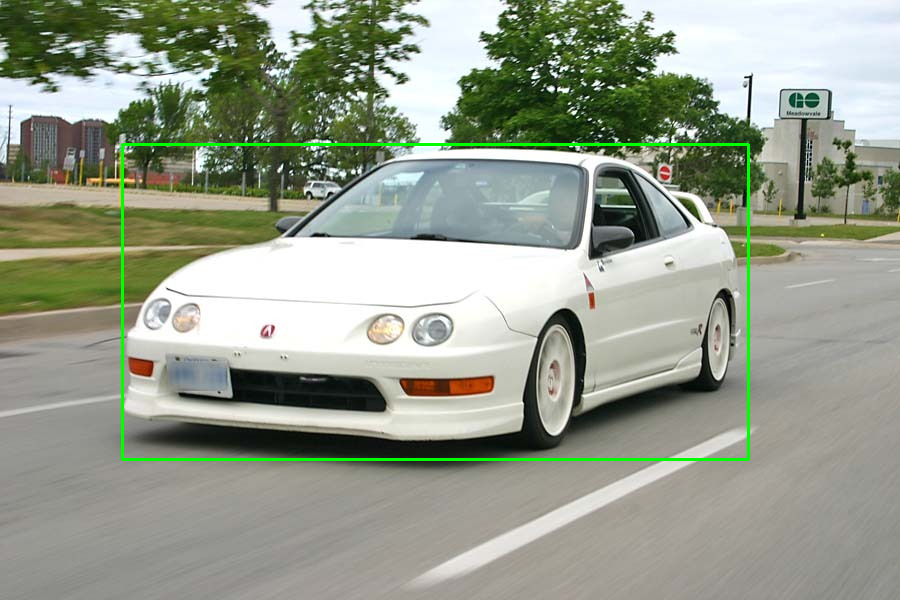

In [ ]:
# Define the bounding box coordinates
bbox_x, bbox_y = int(df[df["image_name"] == "00128.jpg"] ["bbox_x"].values), int(df[df["image_name"] == "00128.jpg"] ["bbox_y"].values)
bbox_width, bbox_height = int(df[df["image_name"] == "00128.jpg"] ["bbox_width"].values), int(df[df["image_name"] == "00128.jpg"] ["bbox_height"].values)

# Top-left and bottom-right corners
top_left = (bbox_x, bbox_y)
bottom_right = (bbox_x + bbox_width, bbox_y + bbox_height)

# Draw rectangle
thickness = 2
color = (0, 255, 0) # green
cv2.rectangle(image, top_left, bottom_right,color, thickness)

# Show image
cv2_imshow(image)

In [ ]:
creer tout les fonction personaliser dans fichier.py et appelet, sala7 anglias wa rigil github

Create 3 folder contain train,val and test images and labels

In [ ]:
# create a new folder
import os
folder_name = "/content/car image"
os.makedirs(folder_name, exist_ok=True)

In [ ]:
labels = ["Acura RL Sedan 2012", "Acura Integra Type R 2001", "Acura TL Sedan 2012"]

for i in range(len(labels)):

 folders = [
    "/content/car image/"+labels[i]+"/train/images",
    "/content/car image/"+labels[i]+"/validation/images",
    "/content/car image/"+labels[i]+"/test/images",

    "/content/car image/"+labels[i]+"/train/labels",
    "/content/car image/"+labels[i]+"/validation/labels",
    "/content/car image/"+labels[i]+"/test/labels",
 ]

 for f in folders:
    Path(f).mkdir(parents=True, exist_ok=True)

def copy image from annotion Amal to the car image (train, val, test subfolder)

In [ ]:
# image_names: Liste des noms des images à copier
# source_folder :
# dest_folder :

def copy_image_from_dest_folder_2_source_folder(source_folder, dest_folder, image_names):

 os.makedirs(dest_folder, exist_ok=True)

 for img in image_names:
    src_path = os.path.join(source_folder, img)
    dst_path = os.path.join(dest_folder, img)

    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
        print(f"Copied: {img}")
    else:
        print(f"Not found: {img}")

def copy lables (file.txt) from annotion Amal to the car image (train, val, test subfolder)

In [ ]:
# src_folder
# dst_folder
# src_folder

def copy_text_from_dest_folder_2_source_folder(src_folder, dst_folder, files):

 os.makedirs(dst_folder, exist_ok=True)

 for f in files:
    src = os.path.join(src_folder, f)
    dst = os.path.join(dst_folder, f)

    if os.path.exists(src):
        shutil.copy2(src, dst)
    else:
        print(f"File not found: {src}")

def  Find the subfolder that contains the files.txt (correspond to YOLO annotion)


In [ ]:
# Find the subfolder that contains the files.txt (correspond to YOLO annotion)

# chemin

def search_folder_contain_txt_files (chemin) :

 base_path = Path(chemin)

 for folder in base_path.rglob("*"):
    if folder.is_dir():
        files = list(folder.iterdir())

        # check: folder is not empty AND all files are .txt
        if files and all(f.is_file() and f.suffix == ".txt" for f in files):
            print(folder)
            break
 return str(folder)

Split data for train, tst and validation

In [ ]:
for i in range (len(labels)):

# find the csv file that contain the nome of image and bounding box (file gerated by max...)
  chemin = "/content/Car_data/"+labels[i]+"/"+labels[i]+"/"
  csv_file = glob.glob(chemin + "/*.csv")

# Read csv_file
  df = pd.read_csv(csv_file[0])

# Split indices

  # 70% train , 30 % test & validation for each label
  train_idx, test_val_idx = train_test_split(df.index, test_size=0.3, random_state=42)

  # from test_val_idx : 10% validation , 20% test (approximativment)
  test_idx, val_idx = train_test_split(test_val_idx, test_size=0.3, random_state=42)

# find the corresponding train, val and test image name using the corresponding index
  train_image = np.array((df.iloc[train_idx]).image_name)
  test_image = np.array((df.iloc[test_idx]).image_name)
  val_image = np.array((df.iloc[val_idx]).image_name)


 # copy image from annotion Amal to the car image (train, val, test subfolder)
  copy_image_from_dest_folder_2_source_folder("/content/Car_data/"+labels[i]+"/"+labels[i]+"/",
                                              "/content/car image/"+labels[i]+"/train/images", train_image)

  copy_image_from_dest_folder_2_source_folder("/content/Car_data/"+labels[i]+"/"+labels[i]+"/",
                                              "/content/car image/"+labels[i]+"/validation/images", val_image)

  copy_image_from_dest_folder_2_source_folder("/content/Car_data/"+labels[i]+"/"+labels[i]+"/",
                                              "/content/car image/"+labels[i]+"/test/images", test_image)


 # copy labels from annotion Amal to the car image (train, val, test subfolder)
  copy_text_from_dest_folder_2_source_folder(search_folder_contain_txt_files (chemin),
                                              "/content/car image/"+labels[i]+"/train/labels",
                                              np.char.replace(np.array(train_image, dtype=str), '.jpg', '.txt'))

  copy_text_from_dest_folder_2_source_folder(search_folder_contain_txt_files (chemin),
                                              "/content/car image/"+labels[i]+"/validation/labels",
                                              np.char.replace(np.array(val_image, dtype=str), '.jpg', '.txt'))

  copy_text_from_dest_folder_2_source_folder(search_folder_contain_txt_files (chemin),
                                              "/content/car image/"+labels[i]+"/test/labels",
                                               np.char.replace(np.array(test_image, dtype=str), '.jpg', '.txt'))


Copied: 01891.jpg
Copied: 00249.jpg
Copied: 01034.jpg
Copied: 03525.jpg
Copied: 04244.jpg
Copied: 04920.jpg
Copied: 01856.jpg
Copied: 05260.jpg
Copied: 07960.jpg
Copied: 07897.jpg
Copied: 06762.jpg
Copied: 06990.jpg
Copied: 03690.jpg
Copied: 06571.jpg
Copied: 06061.jpg
Copied: 05295.jpg
Copied: 03405.jpg
Copied: 03011.jpg
Copied: 00183.jpg
Copied: 06250.jpg
Copied: 03325.jpg
Copied: 00849.jpg
Copied: 06839.jpg
Copied: 02223.jpg
Copied: 03593.jpg
Copied: 00691.jpg
Copied: 04892.jpg
Copied: 00858.jpg
Copied: 07330.jpg
Copied: 01635.jpg
Copied: 00459.jpg
Copied: 05261.jpg
Copied: 04663.jpg
Copied: 02669.jpg
Copied: 05259.jpg
Copied: 04011.jpg
Copied: 07841.jpg
Copied: 04486.jpg
Copied: 02065.jpg
Copied: 02035.jpg
Copied: 03537.jpg
Copied: 06624.jpg
Copied: 04381.jpg
Copied: 00913.jpg
Copied: 04638.jpg
Copied: 03875.jpg
Copied: 04311.jpg
Copied: 06469.jpg
Copied: 05930.jpg
Copied: 00580.jpg
Copied: 02540.jpg
Copied: 03306.jpg
Copied: 03792.jpg
Copied: 01031.jpg
Copied: 03317.jpg
Copied: 00

3. Install Requirements (Ultralytics)

Next, we'll install the Ultralytics library in this Google Colab instance. This Python library will be used to train the YOLO model.



In [ ]:
!pip install ultralytics

Create "classes.txt" file to get list of class names

In [ ]:
classes = labels

with open('classes.txt', 'w') as f:
    for c in classes:
        f.write(c + '\n')

4. Configure Training

There's one last step before we can run training: we need to create the Ultralytics training configuration YAML file. This file specifies the location of your train and validation data, and it also defines the model's classes. An example configuration file model is available here.

Run the code block below to automatically generate a data.yaml configuration file. Make sure you have a labelmap file located at custom_data/classes.txt. If you used Label Studio or one of my pre-made datasets, it should already be present. If you assembled the dataset another way, you may have to manually create the classes.txt file (see here for an example of how it's formatted).


Dataset YAML

A YAML (Yet Another Markup Language) file is used to define the dataset configuration. It contains information about the dataset's paths, classes, and other relevant information. I

In [ ]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml


def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
        'train':
        ['/content/car image/Acura Integra Type R 2001/train',
        '/content/car image/Acura RL Sedan 2012/train',
        '/content/car image/Acura TL Sedan 2012/train'],

        'val':
        ['/content/car image/Acura Integra Type R 2001/validation',
        '/content/car image/Acura RL Sedan 2012/validation',
        '/content/car image/Acura TL Sedan 2012/validation' ],

       'nc': number_of_classes,
       'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/classes.txt'
path_to_data_yaml =   '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

train:
- /content/car image/Acura Integra Type R 2001/train
- /content/car image/Acura RL Sedan 2012/train
- /content/car image/Acura TL Sedan 2012/train
val:
- /content/car image/Acura Integra Type R 2001/validation
- /content/car image/Acura RL Sedan 2012/validation
- /content/car image/Acura TL Sedan 2012/validation
nc: 3
names:
- Acura RL Sedan 2012
- Acura Integra Type R 2001
- Acura TL Sedan 2012


Train model

In [ ]:
What happens when you run it:
Loads pretrained weights (yolo11s.pt)
Reads dataset from data.yaml
Trains model for 2 epochs
Saves results in: /content/runs/detect/train #by default


SyntaxError: invalid syntax (1085379843.py, line 1)

des question: model il prend architecture et train ou bien il est train sur les données et on ajoute nos données ?
Le modèle YOLO :

Un modèle comme yolo11s.pt est déjà entraîné (pretrained) sur un grand dataset (ex: COCO).

Donc il contient déjà :

- 📦 des poids appris
- 👁️ une “compréhension générale” des objets (personnes, voitures, animaux…)

2. Transfer Learning (fine-tuning) ⭐ (TON CAS) : Tu ajoutes tes propres données.

👉 Ici :

- ✔ le modèle est déjà pré-entraîné sur une architecture + dataset général
- ✔ tu peux ensuite ajouter tes propres données pour l’adapter

In [ ]:
Interprétation simple
🔹 mAP50
↑ haut = bon → le modèle détecte bien les objets
↓ bas = mauvais → il rate des objets
🔹 mAP50-90 (ou 50-95)
↑ haut = très bon → détection précise
↓ bas = approximatif → boîtes mal ajustées

In [ ]:
import shutil

def delete():

 shutil.rmtree("/content/runs") # delte foder
 shutil.rmtree("/content/predictions") # delte foder
 shutil.rmtree("/content/predictions2") # delte foder
 shutil.rmtree("/content/predictions3") # delte foder

delete()

In [ ]:
!yolo detect train data=/content/data.yaml model=yolo11n.pt epochs=100 imgsz=640

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

6.Test Model (predection)

In [ ]:
!yolo detect predict \
model=/content/runs/detect/train/weights/best.pt \
source="/content/car image/Acura Integra Type R 2001/test/images" \
project="/content/"\
name="predictions" \
save=True

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/62 /content/car image/Acura Integra Type R 2001/train/images/00128.jpg: 448x640 (no detections), 174.4ms
image 2/62 /content/car image/Acura Integra Type R 2001/train/images/00130.jpg: 384x640 (no detections), 153.9ms
image 3/62 /content/car image/Acura Integra Type R 2001/train/images/00255.jpg: 352x640 (no detections), 144.0ms
image 4/62 /content/car image/Acura Integra Type R 2001/train/images/00308.jpg: 384x640 (no detections), 133.3ms
image 5/62 /content/car image/Acura Integra Type R 2001/train/images/00374.jpg: 480x640 (no detections), 200.0ms
image 6/62 /content/car image/Acura Integra Type R 2001/train/images/00386.jpg: 448x640 (no detections), 157.9ms
image 7/62 /content/car image/Acura Integra Type R 2001/train/images/00565.jpg: 448x640 (no detections), 141.5ms
image 8/62 /content/car image/Acura Integ

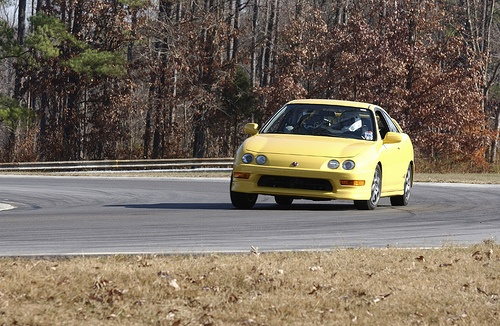

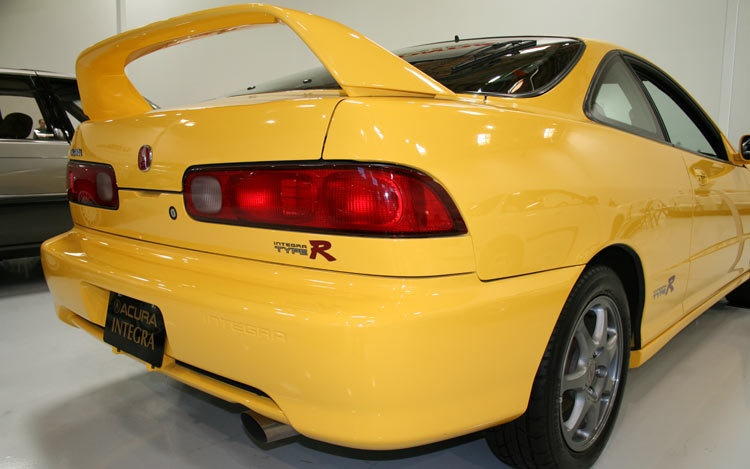

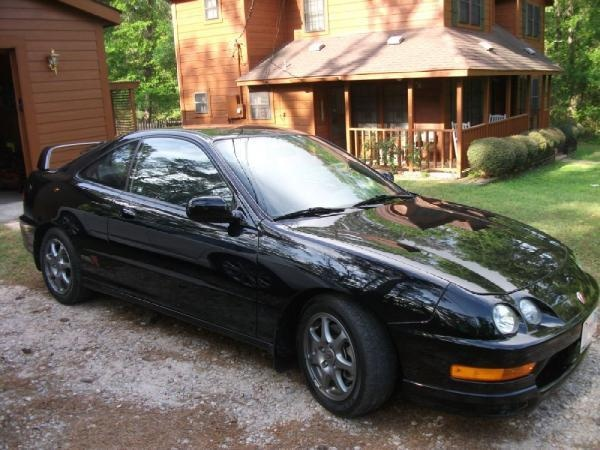

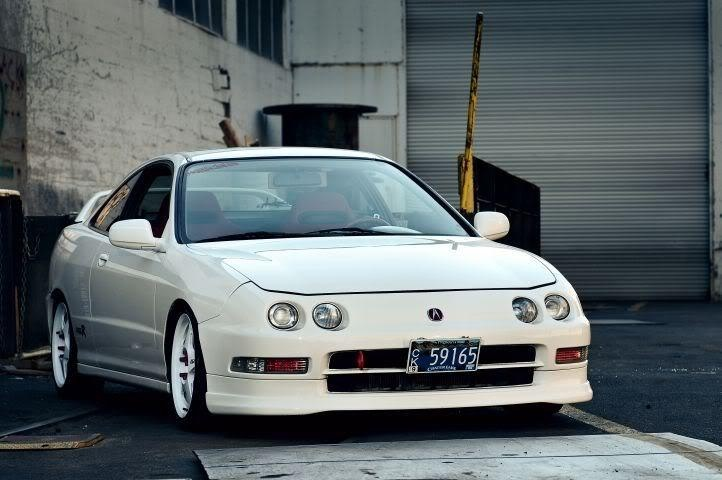

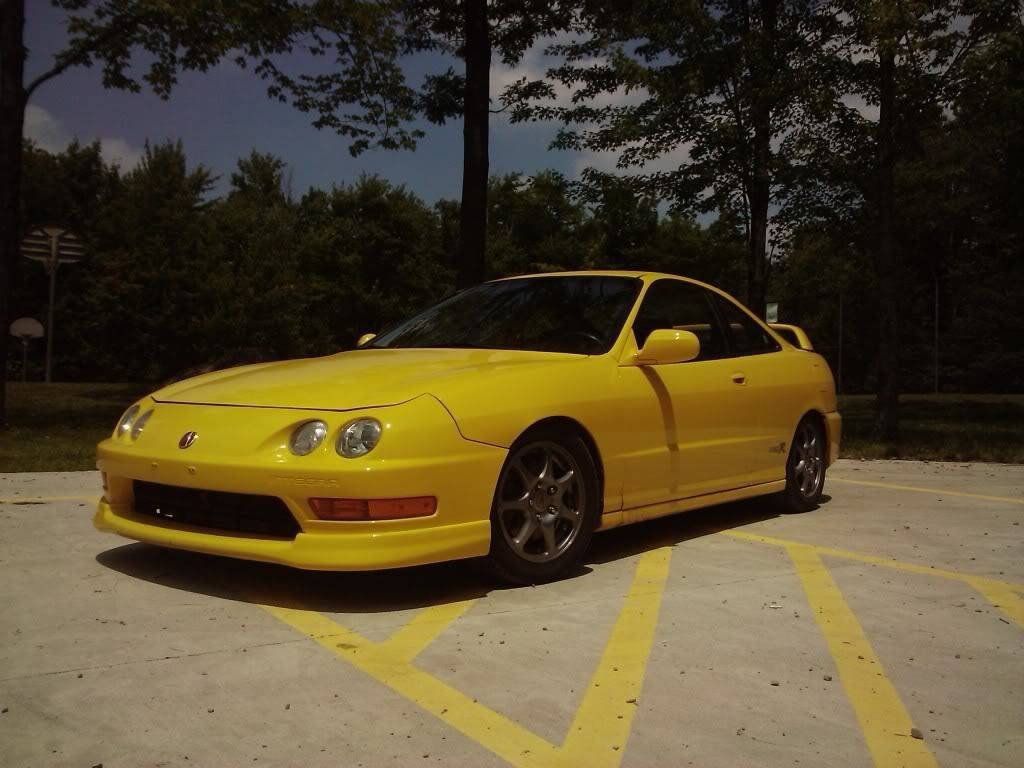

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/predictions/*.jpg')[:5]:
  display(Image(filename=image_path, height=400))
  print('\n')

In [ ]:
!yolo detect predict \
model=/content/runs/detect/train/weights/best.pt \
source="/content/car image/Acura RL Sedan 2012/test/images" \
project="/content/"\
name="predictions2" \
save=True

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/14 /content/car image/Acura RL Sedan 2012/test/images/00347.jpg: 256x640 (no detections), 112.1ms
image 2/14 /content/car image/Acura RL Sedan 2012/test/images/00670.jpg: 448x640 (no detections), 183.2ms
image 3/14 /content/car image/Acura RL Sedan 2012/test/images/01031.jpg: 256x640 (no detections), 94.1ms
image 4/14 /content/car image/Acura RL Sedan 2012/test/images/01535.jpg: 320x640 (no detections), 135.8ms
image 5/14 /content/car image/Acura RL Sedan 2012/test/images/01698.jpg: 416x640 (no detections), 176.9ms
image 6/14 /content/car image/Acura RL Sedan 2012/test/images/02314.jpg: 448x640 (no detections), 158.7ms
image 7/14 /content/car image/Acura RL Sedan 2012/test/images/02540.jpg: 480x640 (no detections), 171.1ms
image 8/14 /content/car image/Acura RL Sedan 2012/test/images/03267.jpg: 448x640 (no detect

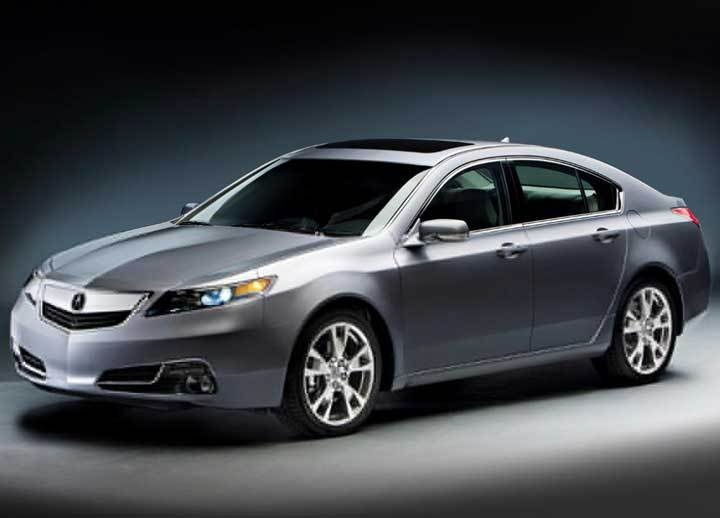

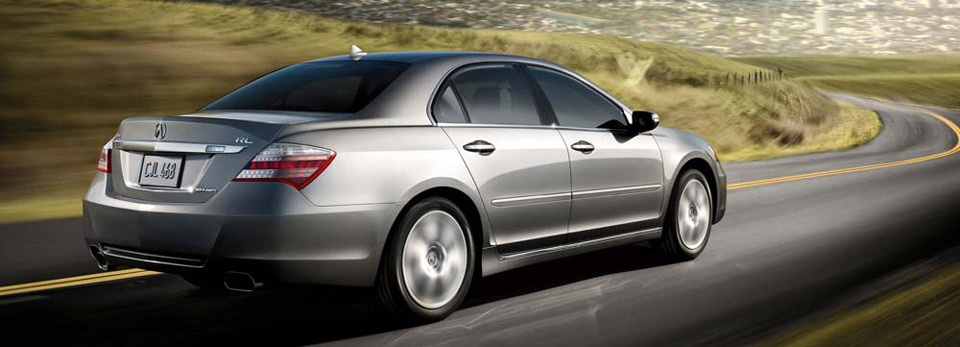

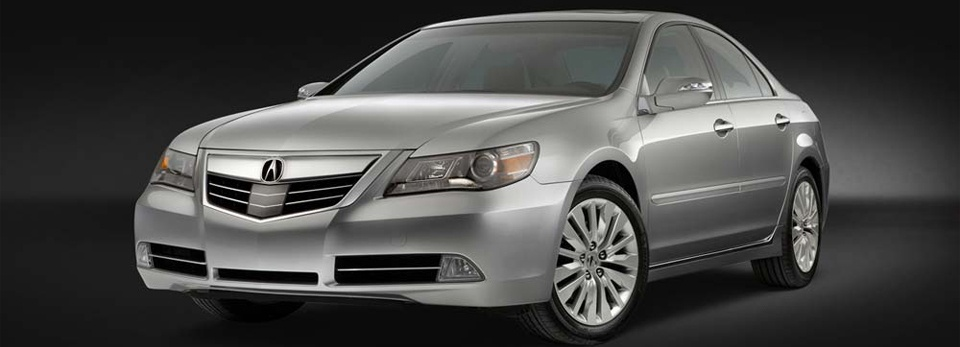

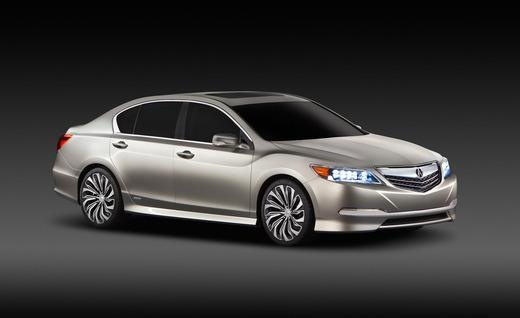

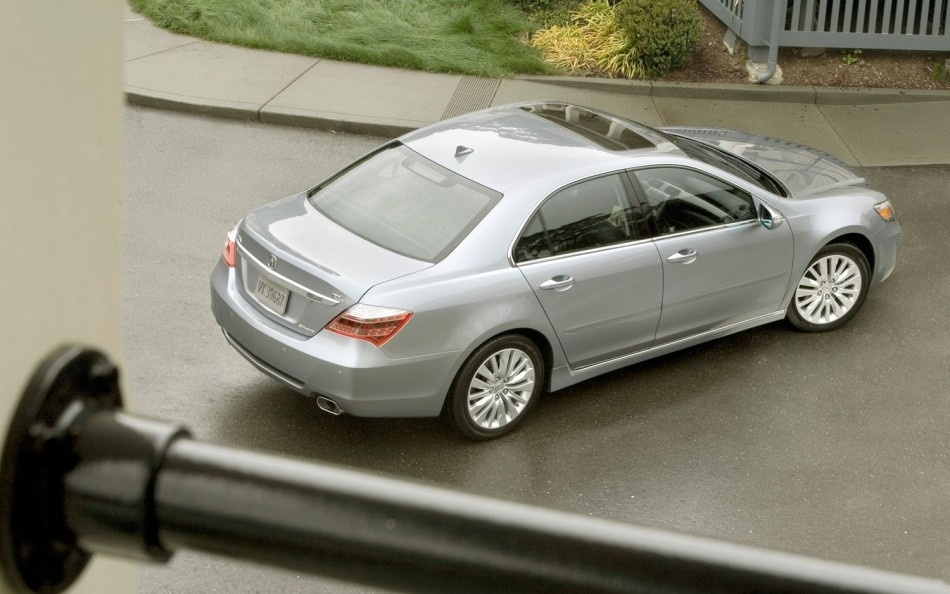

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/predictions2/*.jpg')[:5]:
  display(Image(filename=image_path, height=400))
  print('\n')

In [ ]:
!yolo detect predict \
model=/content/runs/detect/train/weights/best.pt \
source="/content/car image/Acura TL Sedan 2012/test/images" \
project="/content/"\
name="predictions3" \
save=True

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs

image 1/60 /content/car image/Acura TL Sedan 2012/train/images/00043.jpg: 448x640 1 Acura RL Sedan 2012, 82.8ms
image 2/60 /content/car image/Acura TL Sedan 2012/train/images/00282.jpg: 480x640 1 Acura RL Sedan 2012, 80.1ms
image 3/60 /content/car image/Acura TL Sedan 2012/train/images/00314.jpg: 416x640 1 Acura RL Sedan 2012, 77.9ms
image 4/60 /content/car image/Acura TL Sedan 2012/train/images/00397.jpg: 448x640 1 Acura RL Sedan 2012, 10.2ms
image 5/60 /content/car image/Acura TL Sedan 2012/train/images/00595.jpg: 384x640 1 Acura RL Sedan 2012, 84.6ms
image 6/60 /content/car image/Acura TL Sedan 2012/train/images/00740.jpg: 416x640 1 Acura RL Sedan 2012, 11.0ms
image 7/60 /content/car image/Acura TL Sedan 2012/train/images/00793.jpg: 480x640 1 Acura RL Sedan 2012, 10.5ms
image 8/60 /content/car image/Acura TL Sedan 201

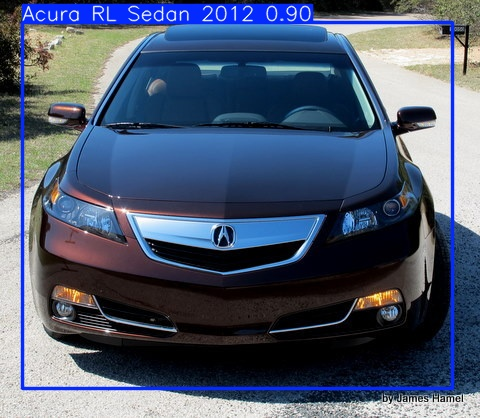

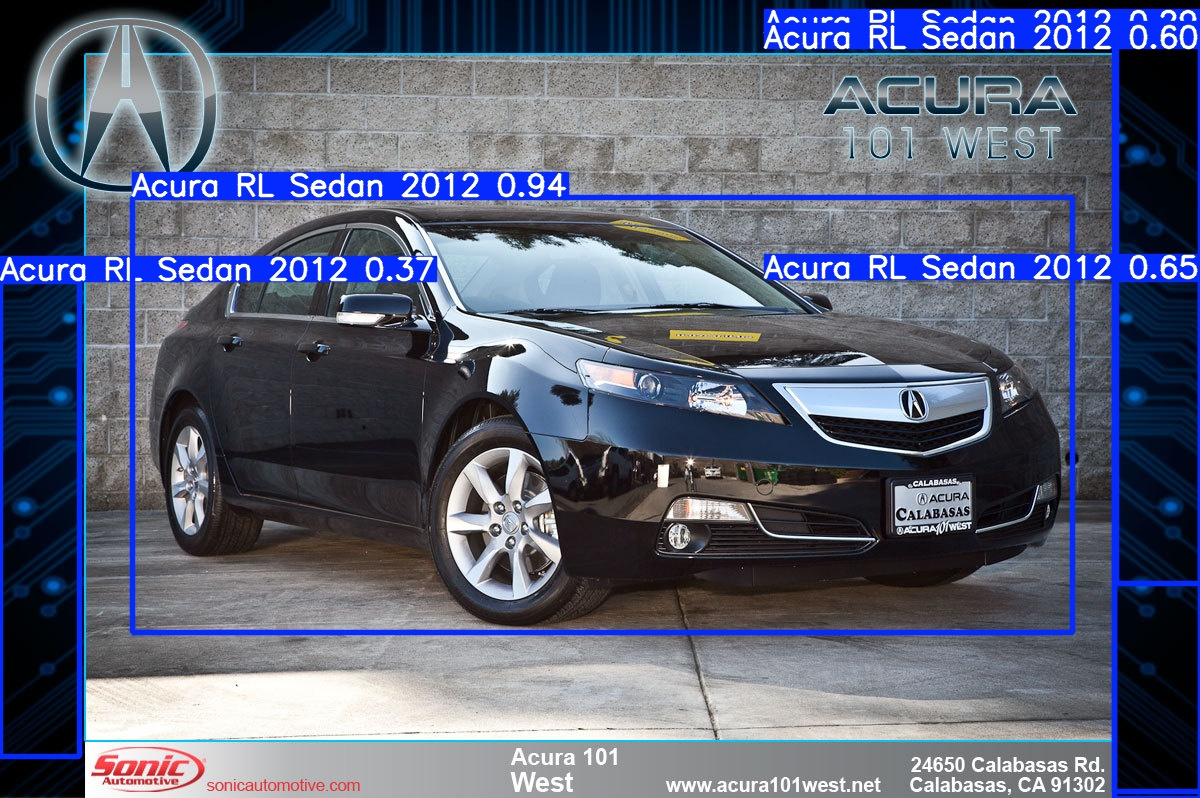

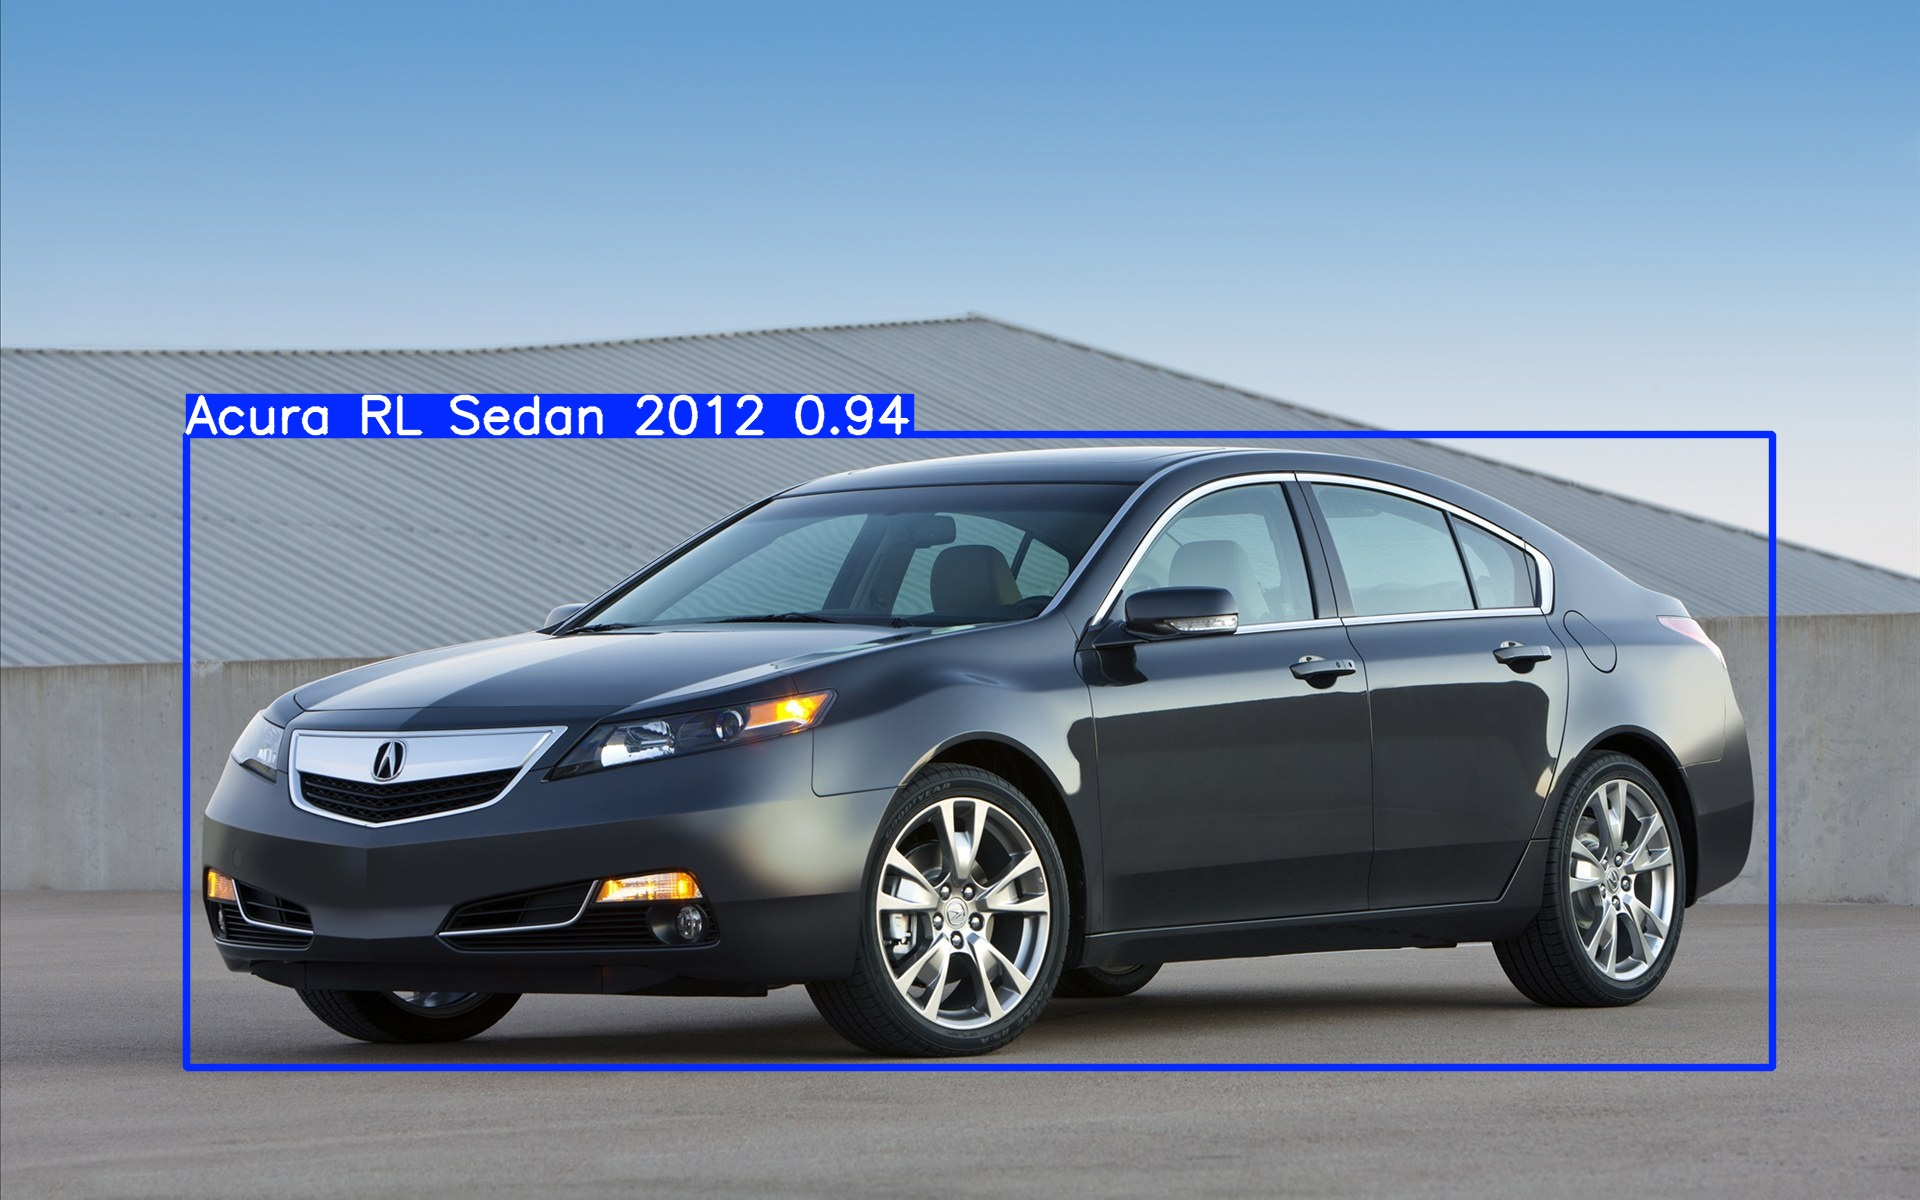

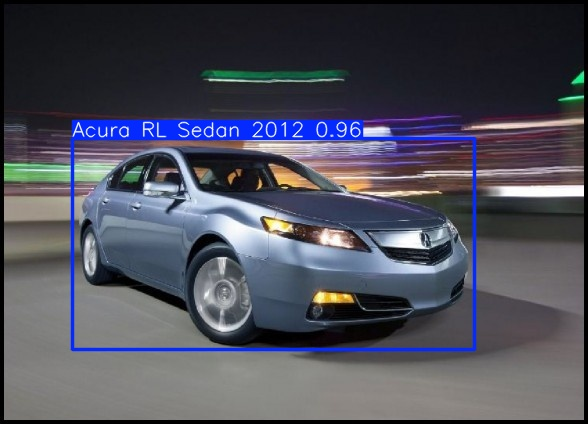

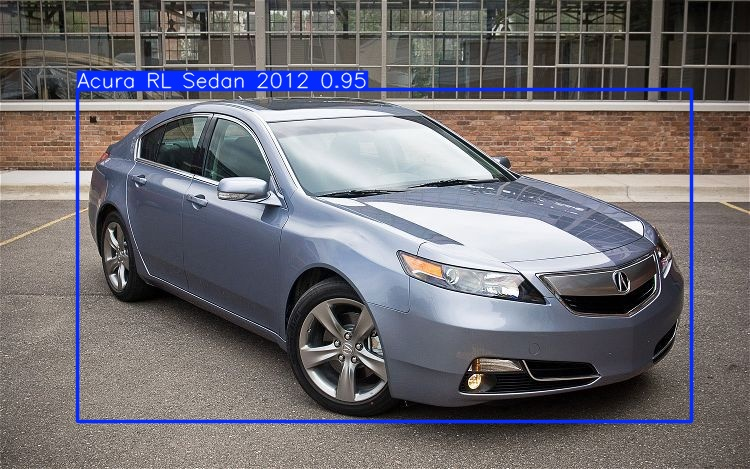

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/predictions3/*.jpg')[:5]:
  display(Image(filename=image_path, height=400))
  print('\n')